In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
dft=pd.read_csv("/content/online_retail.csv",encoding='ISO-8859-1')
dft

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
35127,539434,22847,BREAD BIN DINER STYLE IVORY,1,2010-12-17 14:41:00,34.00,NaN,United Kingdom
35128,539434,22851,SET 20 NAPKINS FAIRY CAKES DESIGN,2,2010-12-17 14:41:00,1.66,NaN,United Kingdom
35129,539434,22854,CREAM SWEETHEART EGG HOLDER,1,2010-12-17 14:41:00,11.02,NaN,United Kingdom
35130,539434,22855,FINE WICKER HEART,7,2010-12-17 14:41:00,2.51,NaN,United Kingdom


In [3]:
dft.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
dft.describe()

,Quantity,UnitPrice,CustomerID
count,35132.000000,35132.000000,24185.000000
mean,8.320762,6.228195,15550.017986
std,63.255184,153.054284,1728.977226
min,-9360.000000,0.000000,12347.000000
25%,1.000000,1.250000,14256.000000
50%,2.000000,2.510000,15574.000000
75%,8.000000,4.250000,17188.000000
max,2880.000000,13541.330000,18269.000000


In [5]:
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35132 entries, 0 to 35131
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    35132 non-null  object 
 1   StockCode    35132 non-null  object 
 2   Description  35015 non-null  object 
 3   Quantity     35132 non-null  int64  
 4   InvoiceDate  35132 non-null  object 
 5   UnitPrice    35132 non-null  float64
 6   CustomerID   24185 non-null  float64
 7   Country      35132 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 2.1+ MB


In [6]:
dft.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,117
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,10947
Country,0


In [7]:
dft=dft.dropna(subset=['CustomerID'])

In [8]:
dft=dft[dft['Quantity']>0]

In [9]:
dft=dft[dft['UnitPrice']>0]

In [10]:
dft=dft.drop_duplicates()

In [11]:
dft['TotalAmount'] = dft['Quantity'] * dft['UnitPrice']

In [12]:
dft['InvoiceDate'] = pd.to_datetime(dft['InvoiceDate'])

In [13]:
reference_date = dft['InvoiceDate'].max()

In [14]:
recency = dft.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (reference_date - recency['InvoiceDate']).dt.days
recency = recency[['CustomerID', 'Recency']]

In [15]:
frequency = dft.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency.columns = ['CustomerID', 'Frequency']

In [16]:
monetary = dft.groupby('CustomerID')['TotalAmount'].sum().reset_index()
monetary.columns = ['CustomerID', 'Monetary']

In [17]:
rfm = recency.merge(frequency, on='CustomerID')
rfm = rfm.merge(monetary, on='CustomerID')

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12347.0,9,1,711.79
1,12348.0,0,1,892.80
2,12370.0,0,2,1864.27
3,12386.0,9,1,258.90
4,12395.0,13,1,346.10


In [18]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [19]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

In [20]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [21]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [22]:
def segment_customer(row):
    if row['RFM_Score'] in ['555','554','545','544']:
        return 'High Value'
    elif row['RFM_Score'] in ['445','444','435']:
        return 'Loyal Customers'
    elif row['RFM_Score'] in ['333','323']:
        return 'Average Customers'
    else:
        return 'Low Value'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [23]:
rfm['Segment'].value_counts()

,count
Segment,
Low Value,725
High Value,74
Loyal Customers,18
Average Customers,15


In [24]:
rfm.to_csv("rfm_output.csv", index=False)

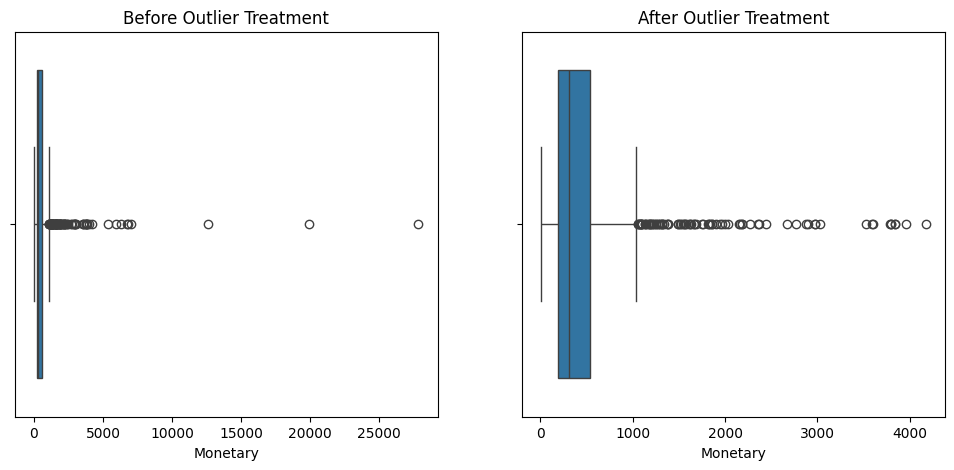

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=rfm['Monetary'])
plt.title("Before Outlier Treatment")

plt.subplot(1,2,2)
sns.boxplot(x=rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.99)]['Monetary'])
plt.title("After Outlier Treatment")

plt.show()

<Axes: xlabel='Monetary_log'>

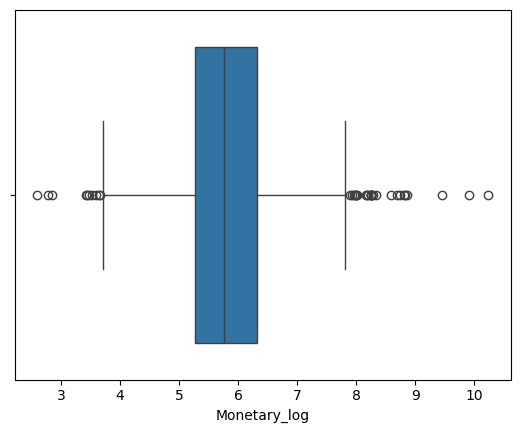

In [26]:
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

sns.boxplot(x=rfm['Monetary_log'])

In [27]:
total_customers = rfm.shape[0]
avg_monetary = rfm['Monetary'].mean()
avg_frequency = rfm['Frequency'].mean()

In [28]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'
    elif row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] >= 4:
        return 'Recent Customers'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

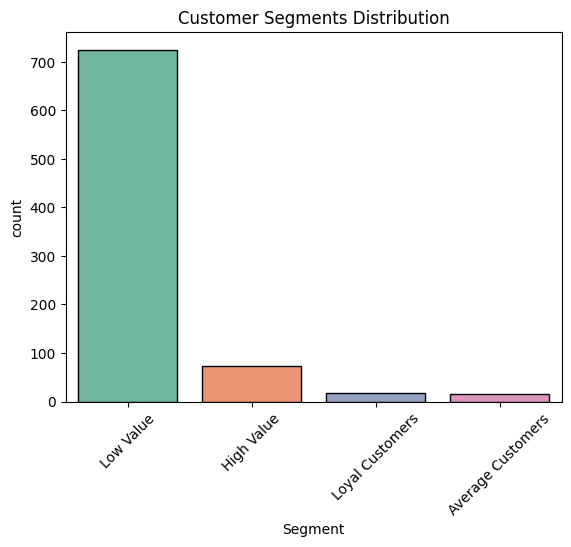

In [29]:
sns.countplot(x='Segment', hue='Segment', data=rfm, palette='Set2',edgecolor='black', linewidth=1)
plt.xticks(rotation=45)
plt.title("Customer Segments Distribution")
plt.legend([], [], frameon=False)
plt.show()

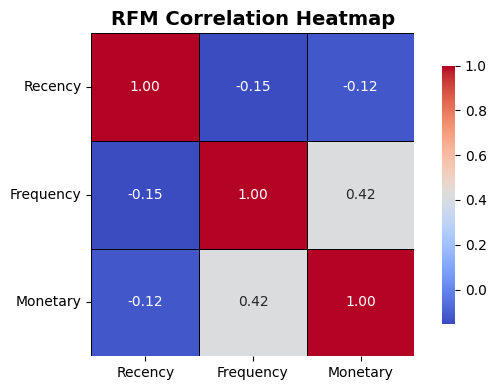

In [30]:
plt.figure(figsize=(6, 4))
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(),annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,linecolor='black',square=True,cbar_kws={"shrink": 0.8},annot_kws={"size": 10})
plt.title("RFM Correlation Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()